In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

sns.set_theme(style="whitegrid")

In [2]:
# Load cleaned datasets

nav_df = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")
trans_df = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")
perf_df = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")

print("NAV Shape:", nav_df.shape)
print("Transactions Shape:", trans_df.shape)
print("Performance Shape:", perf_df.shape)

NAV Shape: (46000, 3)
Transactions Shape: (32778, 13)
Performance Shape: (40, 19)


In [3]:
display(nav_df.head())
display(trans_df.head())
display(perf_df.head())

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


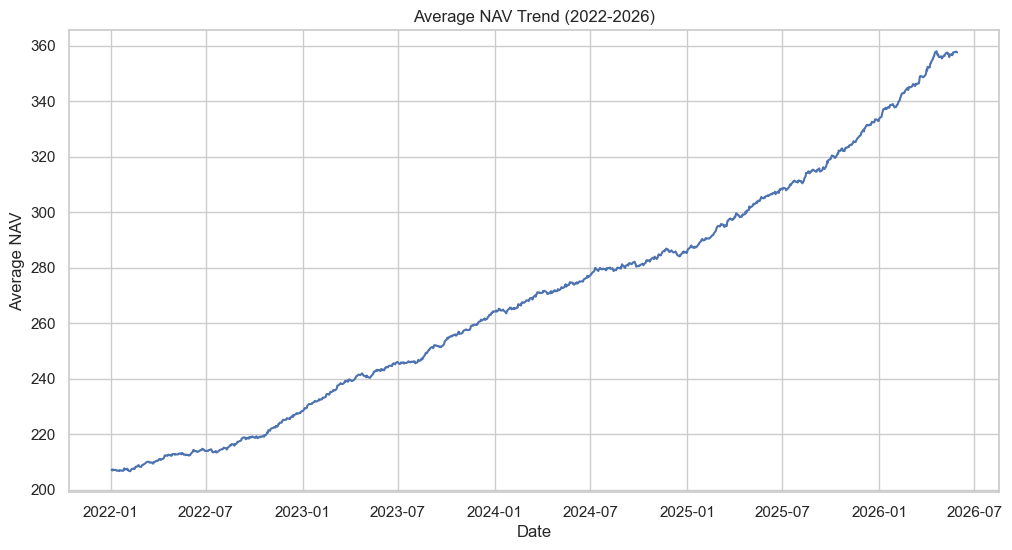

In [4]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

daily_nav = (
    nav_df.groupby("date")["nav"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))
plt.plot(daily_nav["date"], daily_nav["nav"])

plt.title("Average NAV Trend (2022-2026)")
plt.xlabel("Date")
plt.ylabel("Average NAV")

plt.show()

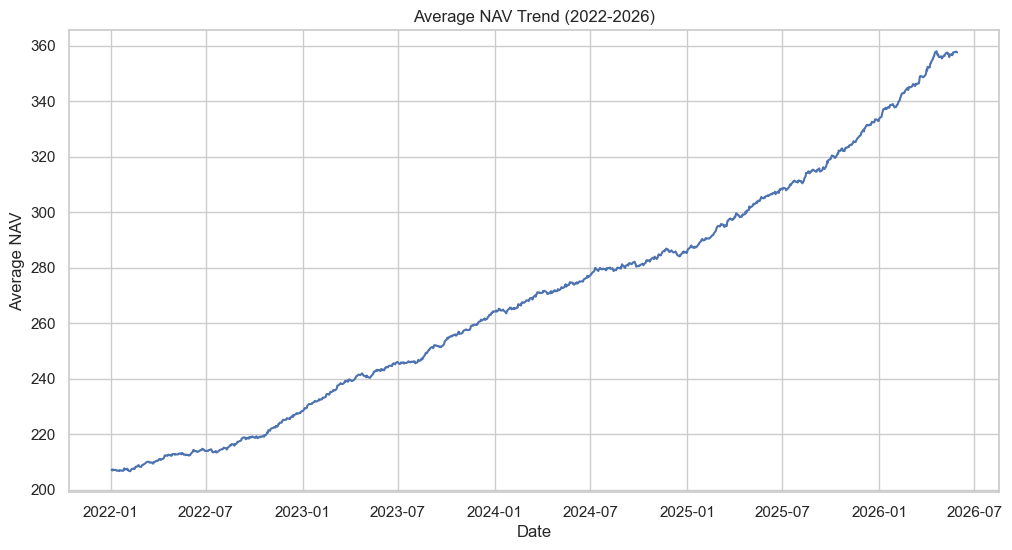

In [5]:
plt.figure(figsize=(12,6))
plt.plot(daily_nav["date"], daily_nav["nav"])

plt.title("Average NAV Trend (2022-2026)")
plt.xlabel("Date")
plt.ylabel("Average NAV")

plt.savefig("../reports/nav_trend.png")
plt.show()

/var/folders/w4/4qgfkc61487gbmrsp16bdv0c0000gp/T/ipykernel_10533/726502540.py:18: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/tanishkasharma/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


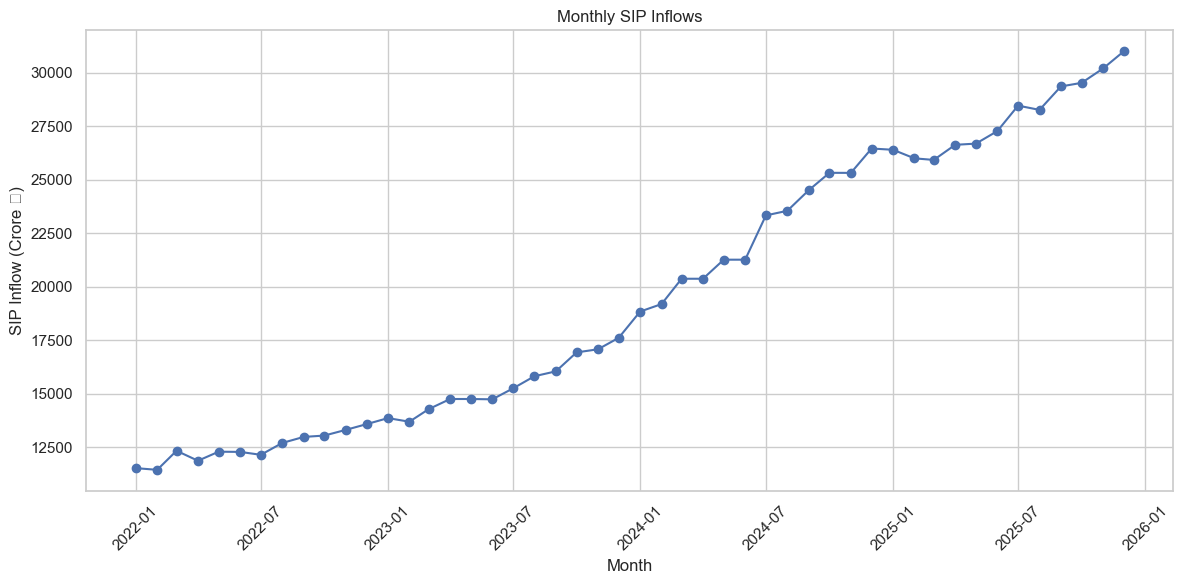

In [6]:
sip_df = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

sip_df["month"] = pd.to_datetime(sip_df["month"])

plt.figure(figsize=(12,6))

plt.plot(
    sip_df["month"],
    sip_df["sip_inflow_crore"],
    marker="o"
)

plt.title("Monthly SIP Inflows")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore ₹)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

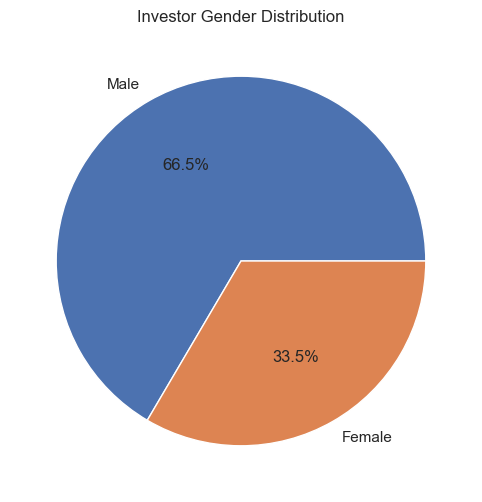

In [7]:
gender_counts = trans_df["gender"].value_counts()

plt.figure(figsize=(8,6))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Gender Distribution")

plt.show()

/Users/tanishkasharma/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


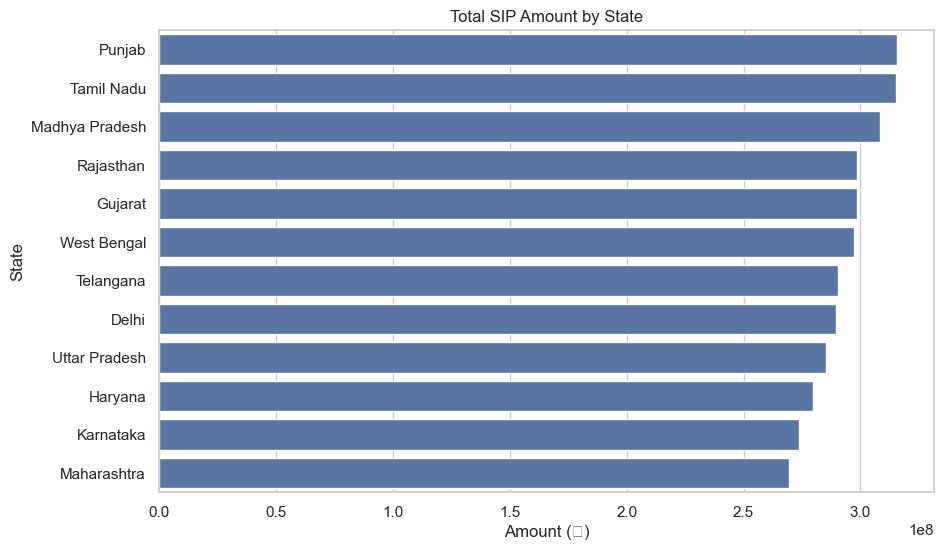

In [8]:
state_sip = (
    trans_df.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=state_sip.values,
    y=state_sip.index
)

plt.title("Total SIP Amount by State")
plt.xlabel("Amount (₹)")
plt.ylabel("State")

plt.show()

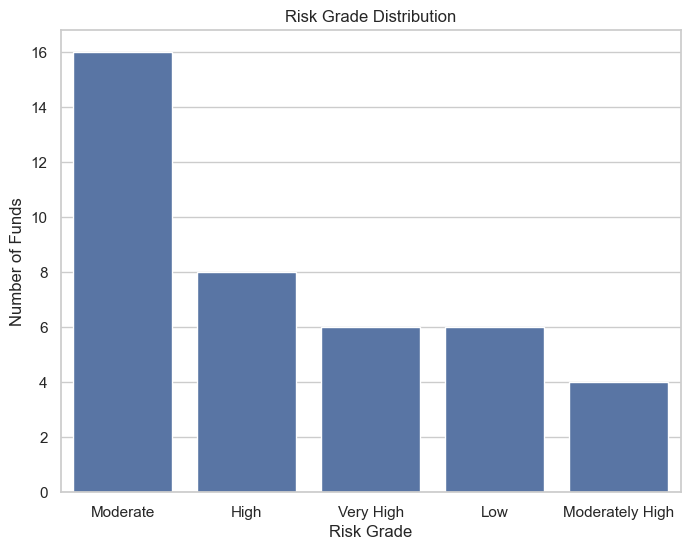

In [9]:
risk_counts = perf_df["risk_grade"].value_counts()

plt.figure(figsize=(8,6))

sns.barplot(
    x=risk_counts.index,
    y=risk_counts.values
)

plt.title("Risk Grade Distribution")
plt.xlabel("Risk Grade")
plt.ylabel("Number of Funds")

plt.show()

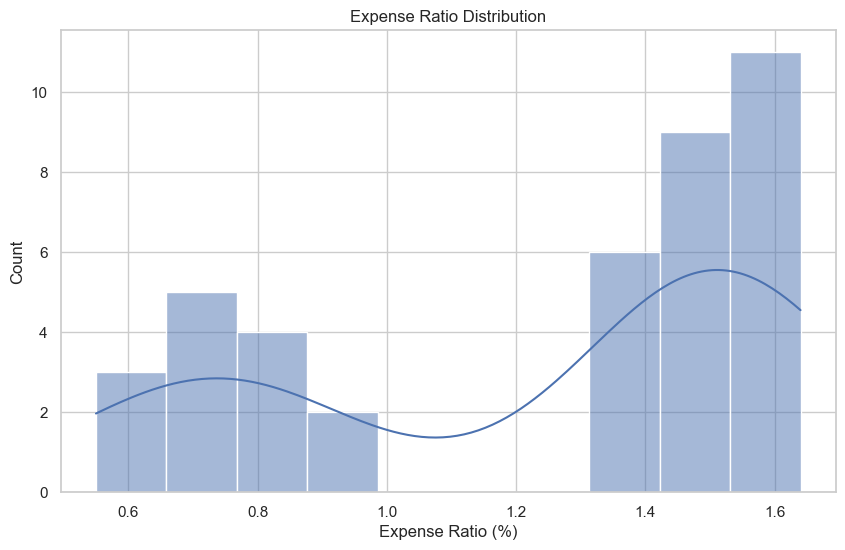

In [10]:
plt.figure(figsize=(10,6))

sns.histplot(
    perf_df["expense_ratio_pct"],
    bins=10,
    kde=True
)

plt.title("Expense Ratio Distribution")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("Count")

plt.show()

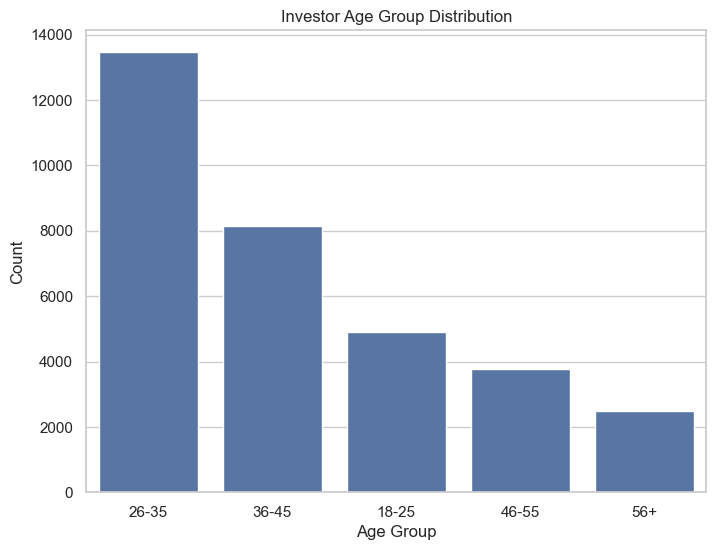

In [11]:
age_counts = trans_df["age_group"].value_counts()

plt.figure(figsize=(8,6))

sns.barplot(
    x=age_counts.index,
    y=age_counts.values
)

plt.title("Investor Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")

plt.show()

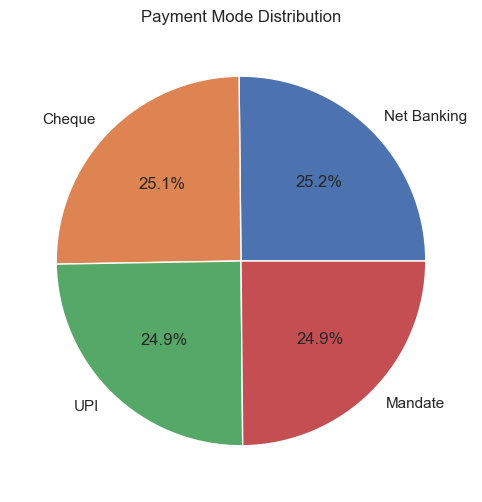

In [12]:
payment_counts = trans_df["payment_mode"].value_counts()

plt.figure(figsize=(8,6))

plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct="%1.1f%%"
)

plt.title("Payment Mode Distribution")

plt.show()

/Users/tanishkasharma/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


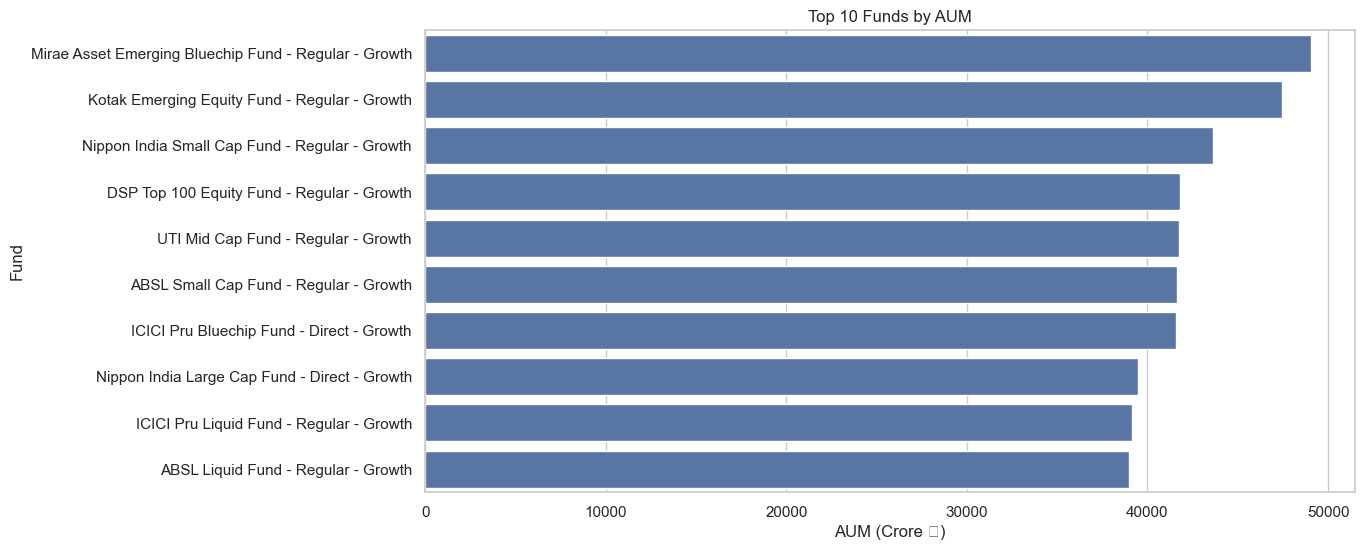

In [13]:
top_aum = (
    perf_df.sort_values(
        "aum_crore",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x="aum_crore",
    y="scheme_name",
    data=top_aum
)

plt.title("Top 10 Funds by AUM")
plt.xlabel("AUM (Crore ₹)")
plt.ylabel("Fund")

plt.show()

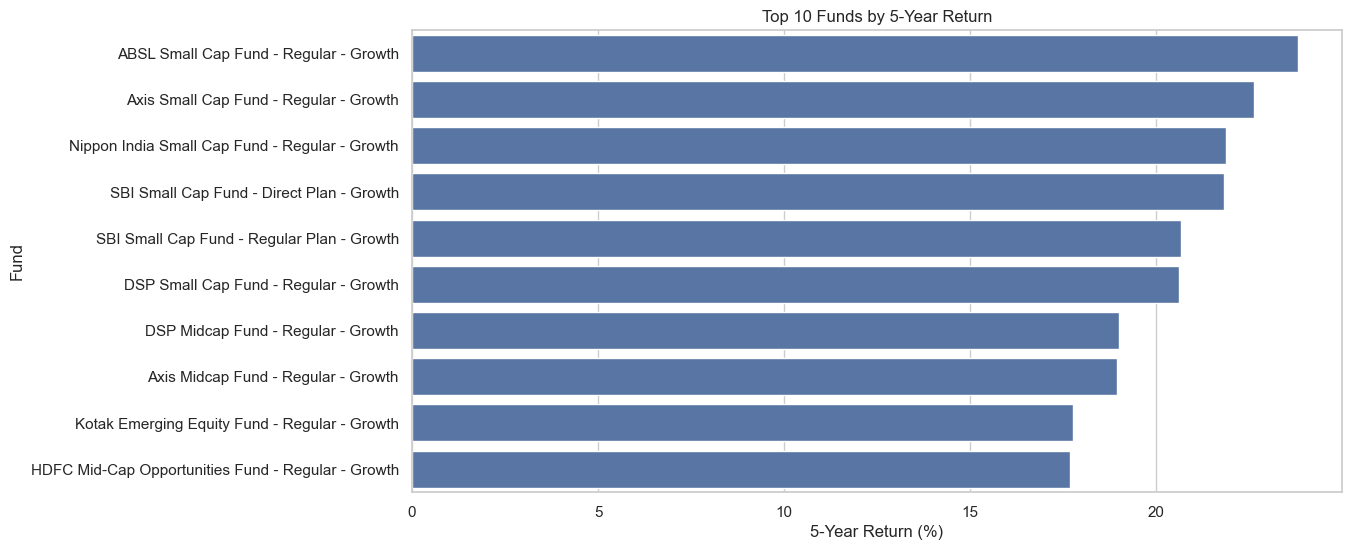

In [14]:
top_return = (
    perf_df.sort_values(
        "return_5yr_pct",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x="return_5yr_pct",
    y="scheme_name",
    data=top_return
)

plt.title("Top 10 Funds by 5-Year Return")
plt.xlabel("5-Year Return (%)")
plt.ylabel("Fund")

plt.show()

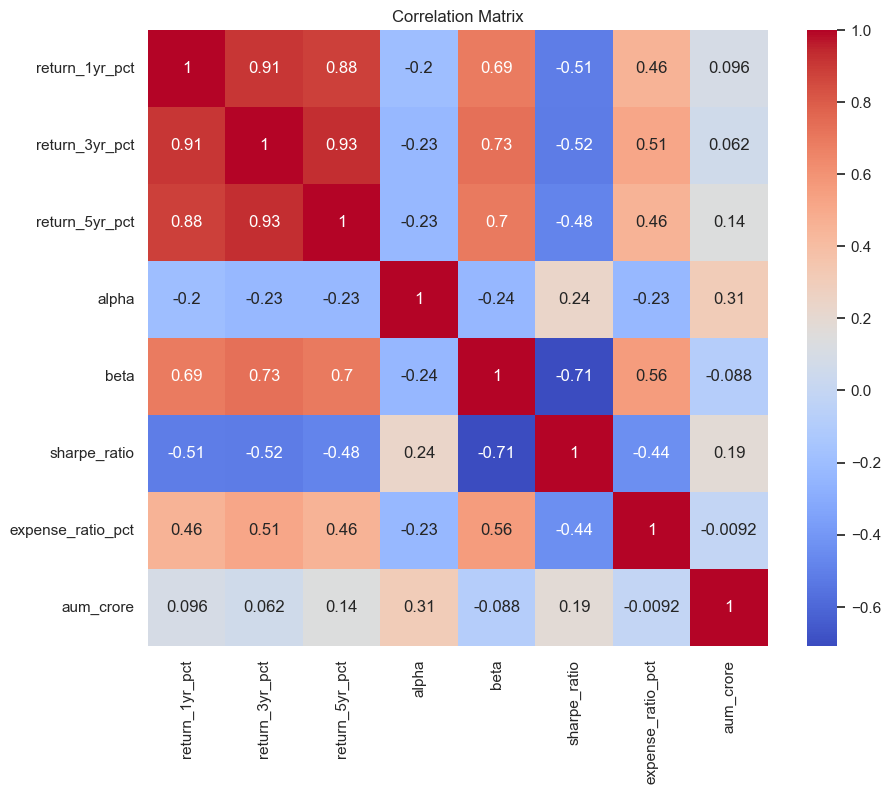

In [15]:
corr_cols = [
    "return_1yr_pct",
    "return_3yr_pct",
    "return_5yr_pct",
    "alpha",
    "beta",
    "sharpe_ratio",
    "expense_ratio_pct",
    "aum_crore"
]

corr = perf_df[corr_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

# Key EDA Findings

1. Average NAV increased steadily from 2022 to 2026.
2. SIP inflows show a long-term upward trend.
3. Equity-oriented funds dominate the dataset.
4. Moderate risk funds form the largest category.
5. Expense ratios are concentrated within a narrow range.
6. AUM is heavily concentrated among a few large schemes.
7. Long-term returns vary significantly across funds.
8. Investor participation is spread across multiple age groups.
9. Digital payment methods dominate investment transactions.
10. Geographic participation is concentrated in major investment states.